<a href="https://colab.research.google.com/github/Nikhil0264/Collab_special/blob/main/Variational_AutoEncoderDecoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# pip install torch torchvision matplotlib numpy

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import dataloader
import matplotlib.pyplot as plt
import numpy as np

In [14]:
class Encoder(nn.Module):
  def __init__(self,input_dim,hidden_dim,latent_dim):
    super(Encoder,self).__init__()
    self.fc1 = nn.Linear(input_dim,hidden_dim)
    self.fc_mu = nn.Linear(hidden_dim,latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim,latent_dim)

  def forward(self,x):
    h = torch.relu(self.fc1(x))
    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)

    return mu,logvar

In [15]:
class Decoder(nn.Module):
  def __init__(self,latent_dim,hidden_dim,output_dim):
    super(Decoder,self).__init__()
    self.fc1 = nn.Linear(latent_dim,hidden_dim)
    self.fc2 = nn.Linear(hidden_dim,output_dim)

  def forward(self,z):
    h = torch.relu(self.fc1(z))
    x_hat = torch.sigmoid(self.fc2(h))

    return x_hat

In [16]:
class VAE(nn.Module):
  def __init__(self,input_dim,hidden_dim,latent_dim):
    super(VAE,self).__init__()
    self.encoder = Encoder(input_dim,hidden_dim,latent_dim)
    self.decoder = Decoder(latent_dim,hidden_dim,input_dim)

  def forward(self,x):
    mu,logvar = self.encoder(x)

    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)

    z = mu + eps*std

    x_hat = self.decoder(z)

    return x_hat,mu,logvar

In [17]:
def loss_function(x,x_hat,mu,logvar):
  BCE = nn.functional.binary_cross_entropy(x_hat,x,reduction='sum')
  KLD = -0.5 * torch.sum(1+ logvar - mu.pow(2) - logvar.exp())

  return BCE+KLD

In [12]:
input_dim = 784
hidden_dim = 400
latent_dim = 20
lr = 1e-3
batch_size = 128
epochs = 10

transform = transforms.Compose([transforms.ToTensor(),transforms.Lambda(lambda x:x.view(-1))])

train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=transform)
train_loader = dataloader.DataLoader(train_dataset,batch_size=batch_size,shuffle=True)



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 460kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.02MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.02MB/s]


In [19]:
vae = VAE(input_dim,hidden_dim,latent_dim)
optimizer = optim.Adam(vae.parameters(),lr=lr)

for epoch in range(epochs):
  train_loss = 0
  for x,_ in train_loader:
    x = x.view(-1,input_dim)
    optimizer.zero_grad()
    x_hat,mu,logvar = vae(x)
    loss = loss_function(x,x_hat,mu,logvar)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  print(f'Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader.dataset)}')

Epoch 1, Train Loss: 164.08463157552083
Epoch 2, Train Loss: 120.88385768229166
Epoch 3, Train Loss: 114.04442454427084
Epoch 4, Train Loss: 111.1280993326823
Epoch 5, Train Loss: 109.30811831054687
Epoch 6, Train Loss: 108.22868372395833
Epoch 7, Train Loss: 107.3676099609375
Epoch 8, Train Loss: 106.76699130859375
Epoch 9, Train Loss: 106.27285122070313
Epoch 10, Train Loss: 105.88644516601562


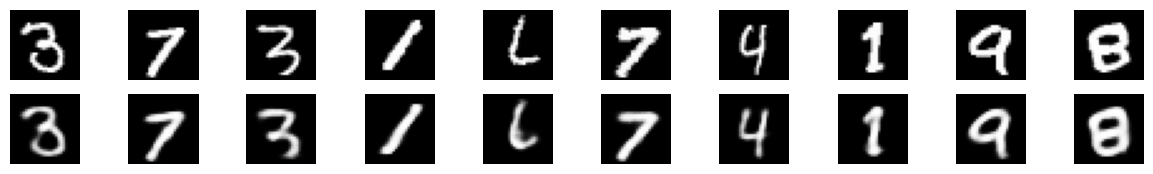

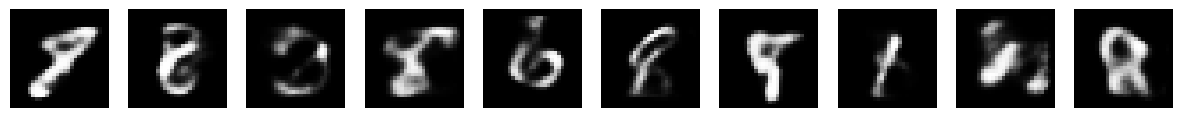

In [26]:
vae.eval()

with torch.no_grad():
  x,_ = next(iter(train_loader))
  x = x.view(-1,input_dim)
  x_hat,_,_ = vae(x)
  x = x.view(-1,28,28)
  x_hat = x_hat.view(-1,28,28)
  fig,axs = plt.subplots(2,10,figsize=(15,2))

  for i in range(10):
    axs[0,i].imshow(x[i].detach().numpy(),cmap='gray')
    axs[1,i].imshow(x_hat[i].detach().numpy(),cmap='gray')

    axs[0,i].axis('off')
    axs[1,i].axis('off')

  plt.show()


with torch.no_grad():

  z = torch.randn(10,latent_dim)
  x_hat = vae.decoder(z)
  x_hat = x_hat.view(-1,28,28)

  fig,axs = plt.subplots(1,10,figsize=(15,3))

  for i in range(10):
    axs[i].imshow(x_hat[i].cpu().numpy(),cmap='gray')

    axs[i].axis('off')
  plt.show()